# Salt Wedge Benchmark: Compare Model Results to Experimental Data

## Overview

This notebook compares model simulation results to salt wedge intrusion experiments conducted by **Goswami and Clement (2007)** published in *Water Resources Research*, volume 43.

### What This Analysis Does:
1. **Loads experimental data** from steady-state salt wedge experiments (3 scenarios)
2. **Reads model results** from VTK output files
3. **Calculates interface positions** at three concentration levels (10%, 50%, 90%)
4. **Compares to analytical solution** using Glover (1959) equation
5. **Computes error metrics** (mean error, RMSE) between model and observations
6. **Visualizes results** showing model vs experimental salt wedge intrusion

### Key References:
- **Goswami & Clement (2007)**: Experimental investigation of salt-wedge intrusion due to tidal pumping
- **Glover (1959)**: Analytical solution for fresh-salt water interface in coastal aquifers

**Author:** Elco Luijendijk  
**Updated to Python 3 and Jupyter Notebook format:** 2026

## Setup: Imports and Configuration

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import vtk
import os
from pathlib import Path

# For interactive widgets (optional)
try:
    from ipywidgets import Text, FloatText, Button, Output, VBox, HBox
    from IPython.display import display, HTML
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("Warning: ipywidgets not available. Running in static mode.")

print("✓ All imports successful")

✓ All imports successful


## Helper Functions

### VTK File Reader
Reads VTU files using the VTK library to extract points, cells, and both point and cell data.

In [38]:
def read_vtu_file_vtk(filename):
    """
    Read VTU (VTK Unstructured Grid) file using VTK library.
    
    This method is robust and handles binary appended data properly.
    
    Parameters
    ----------
    filename : str
        Path to the .vtu file
    
    Returns
    -------
    tuple
        (xy_pts, conn, pt_var_names, pt_var_arrays, cell_var_names, cell_var_arrays)
    """
    
    reader = vtk.vtkXMLUnstructuredGridReader()
    reader.SetFileName(filename)
    reader.Update()
    
    output = reader.GetOutput()
    
    # Get points
    points_vtk = output.GetPoints()
    n_points = points_vtk.GetNumberOfPoints()
    xy_pts = np.zeros((n_points, 3))
    for i in range(n_points):
        p = points_vtk.GetPoint(i)
        xy_pts[i] = p
    
    # Get cells
    cells = output.GetCells()
    n_cells = cells.GetNumberOfCells()
    
    conn = []
    for i in range(n_cells):
        cell = output.GetCell(i)
        n_pts = cell.GetNumberOfPoints()
        pts = [cell.GetPointId(j) for j in range(n_pts)]
        conn.append(pts)
    
    conn = np.array(conn, dtype=object)
    
    # Get cell data
    cell_data = output.GetCellData()
    n_arrays = cell_data.GetNumberOfArrays()
    
    cell_var_names = []
    cell_var_arrays = []
    
    for i in range(n_arrays):
        array = cell_data.GetArray(i)
        name = array.GetName()
        n_comp = array.GetNumberOfComponents()
        n_tuples = array.GetNumberOfTuples()
        
        cell_var_names.append(name)
        
        # Convert to numpy
        data = np.zeros((n_tuples, n_comp))
        for j in range(n_tuples):
            if n_comp == 1:
                data[j, 0] = array.GetValue(j)
            else:
                for k in range(n_comp):
                    data[j, k] = array.GetComponent(j, k)
        
        if n_comp == 1:
            data = data.ravel()
        
        cell_var_arrays.append(data)
    
    # Get point data
    point_data = output.GetPointData()
    n_arrays = point_data.GetNumberOfArrays()
    
    pt_var_names = []
    pt_var_arrays = []
    
    for i in range(n_arrays):
        array = point_data.GetArray(i)
        name = array.GetName()
        n_comp = array.GetNumberOfComponents()
        n_tuples = array.GetNumberOfTuples()
        
        pt_var_names.append(name)
        
        # Convert to numpy
        data = np.zeros((n_tuples, n_comp))
        for j in range(n_tuples):
            if n_comp == 1:
                data[j, 0] = array.GetValue(j)
            else:
                for k in range(n_comp):
                    data[j, k] = array.GetComponent(j, k)
        
        if n_comp == 1:
            data = data.ravel()
        
        pt_var_arrays.append(data)
    
    return xy_pts, conn, pt_var_names, pt_var_arrays, cell_var_names, cell_var_arrays

def map_cell_data_to_points(cell_data, conn, n_points):
    """
    Map cell data to point data by averaging values from neighboring cells.
    
    Parameters
    ----------
    cell_data : array
        Cell-centered data (n_cells,)
    conn : array
        Cell connectivity array (n_cells, n_nodes_per_cell)
    n_points : int
        Number of points in the mesh
    
    Returns
    -------
    array
        Point-centered data (n_points,)
    """
    point_data = np.zeros(n_points)
    point_counts = np.zeros(n_points)
    
    for cell_idx, cell_nodes in enumerate(conn):
        for node_idx in cell_nodes:
            node_idx = int(node_idx)
            point_data[node_idx] += cell_data[cell_idx]
            point_counts[node_idx] += 1
    
    # Avoid division by zero
    valid_points = point_counts > 0
    point_data[valid_points] /= point_counts[valid_points]
    
    return point_data

print("✓ VTU reader function defined")
print("✓ Cell-to-point mapping function defined")

✓ VTU reader function defined
✓ Cell-to-point mapping function defined


### Analytical Solution: Glover (1959)

The Glover equation describes the analytical solution for the fresh-salt water interface depth in a coastal aquifer with a specified freshwater discharge:

$$y = \sqrt{\frac{2Q}{\gamma K}x + \left(\frac{Q}{\gamma K}\right)^2}$$

where:
- $y$ = depth of fresh-salt water interface (m)
- $Q$ = freshwater discharge per unit width (m²/s)
- $K$ = permeability (m/s)
- $\gamma$ = relative density difference = $(\rho_s - \rho_f) / \rho_f$
- $x$ = distance from land (m)

In [28]:
def depth_sw_interface_Glover1959(x, Q, K, rho_f, rho_s):
    """
    Calculate depth of the fresh-salt water interface in a coastal aquifer.
    
    Based on the analytical solution by Glover (1959).
    
    Parameters
    ----------
    x : float or array
        Distance from land (m)
    Q : float
        Freshwater discharge per unit width (m²/s)
    K : float
        Permeability (m/s)
    rho_f : float
        Freshwater density (kg/m³), typically ~998.7
    rho_s : float
        Saltwater density (kg/m³), typically ~1026.0
    
    Returns
    -------
    array
        Depth of fresh-salt interface at each x position (m)
    """
    
    gamma = (rho_s - rho_f) / rho_f
    y2 = 2 * Q / (gamma * K) * x + Q**2 / (gamma**2 * K**2)
    depth = np.sqrt(y2)
    
    return depth

print("✓ Glover analytical function defined")

✓ Glover analytical function defined


## Configuration: File Paths and Parameters

Configure the locations of experimental data and model output files.

In [29]:
# ============================================================================
# CONFIGURATION SECTION - Edit paths as needed
# ============================================================================

# Path to experimental data CSV
fn_exp = 'benchmark_data/table_a1_steady_state_salt_wedge_locations.csv'

# Model output VTK file basenames (without _Elements.vtu extension)
#vtk_files_init = [
#    'benchmark_data/model_runs/runS0_specified_pressure_[0, 68.569]_final_output',
#    'benchmark_data/model_runs/runS1_specified_pressure_[0, 19.591]_final_output',
#    'benchmark_data/model_runs/runS2_specified_pressure_[0, 53.876]_final_output'
#]

vtk_files_init = [
    'model_output/salt_wedge_benchmark/vtk_files/runS0_specified_pressure_[0, 68.569]_final_output',
    'model_output/salt_wedge_benchmark/vtk_files/runS1_specified_pressure_[0, 19.591]_final_output',
    'model_output/salt_wedge_benchmark/vtk_files/runS2_specified_pressure_[0, 53.876]_final_output'
]

#

# Maximum concentration value in model (for defining relative concentration levels)
max_conc = 0.03624

# Relative concentration levels for interface detection (10%, 50%, 90% of max)
target_cs = np.array([0.10, 0.50, 0.90]) * max_conc

# Physical properties
rho_f = 998.7   # Freshwater density (kg/m³)
rho_s = 1026.0  # Saltwater density (kg/m³)
K = 1050.0 / (24.0 * 60.0 * 60.0)  # Permeability (m/s)

# Experimental parameters
dh = np.array([0.012, 0.007, 0.0105])  # Head differences (m)
dx_model = 0.53  # Model domain length (m)
b = 0.26  # Model domain height (m)

# Measured fluxes from experiments (cm³/sec) - need to convert
Qs_measured_raw = np.array([1.42, 0.59, 1.19])  # cm³/sec
model_width_3d = 2.7e-2  # Third dimension width in model (2.7 cm) -> convert to m
Qs = Qs_measured_raw / model_width_3d * 1e-4  # Convert to m²/s

# Output figure settings
output_fig_pdf = 'benchmark_data/model_vs_experimental_salt_wedge.pdf'
output_fig_png = 'benchmark_data/model_vs_experimental_salt_wedge.png'

print("✓ Configuration loaded:")
print(f"  - Experimental data: {fn_exp}")
print(f"  - Model files: {len(vtk_files_init)} scenarios")
print(f"  - Max concentration: {max_conc}")
print(f"  - Target concentrations: {target_cs}")

✓ Configuration loaded:
  - Experimental data: benchmark_data/table_a1_steady_state_salt_wedge_locations.csv
  - Model files: 3 scenarios
  - Max concentration: 0.03624
  - Target concentrations: [0.003624 0.01812  0.032616]


## Step 1: Load Experimental Data

In [30]:
# Read experimental data from CSV
print(f"Loading experimental data from: {fn_exp}")
df_exp = pd.read_csv(fn_exp)

print(f"\n✓ Experimental data loaded")
print(f"  - Shape: {df_exp.shape}")
print(f"  - Columns: {list(df_exp.columns)}")
print(f"\nFirst few rows:")
display(df_exp.head())

Loading experimental data from: benchmark_data/table_a1_steady_state_salt_wedge_locations.csv

✓ Experimental data loaded
  - Shape: (23, 6)
  - Columns: ['x_ss1', 'y_ss1', 'x_ss2', 'y_ss2', 'x_ss3', 'y_ss3']

First few rows:


,x_ss1,y_ss1,x_ss2,y_ss2,x_ss3,y_ss3
0,0.0,13.2,0.0,22.0,0.0,15.5
1,0.2,12.5,0.4,21.5,0.6,14.5
2,1.0,11.5,1.1,20.5,1.5,13.5
3,1.9,10.5,1.9,19.5,2.3,12.5
4,2.8,9.5,3.0,18.5,3.3,11.5


## Step 2: Load and Process Model Results

Read VTK output files and extract concentration data to determine salt wedge interface positions.

In [40]:
# Prepare to read model results
#vtk_files = [f + '_Elements.vtu' for f in vtk_files_init]
vtk_files = [f + '.vtu' for f in vtk_files_init]

xs = []  # x-coordinates of interfaces
ys = []  # y-coordinates of model
concs = []  # concentration fields
freshwater_fluxes = []  # calculated fluxes

print("Loading model results from VTK files...\n")

for i, vtk_file in enumerate(vtk_files):
    print(f"Reading VTK file {i+1}/3: {vtk_file}")
    
    # Read VTU file
    xy, conn, pt_var_names, pt_var_arrays, cell_var_names, cell_var_arrays = \
        read_vtu_file_vtk(vtk_file)
    
    # Extract concentration data from PointData or CellData
    conc = None
    data_source = None
    
    # Try PointData first
    try:
        c_ind = pt_var_names.index('concentration')
        conc = pt_var_arrays[c_ind]
        data_source = "PointData"
    except ValueError:
        pass
    
    # If not in PointData, try CellData
    if conc is None:
        try:
            c_ind = cell_var_names.index('concentration')
            conc_cell = cell_var_arrays[c_ind]
            # Map cell data to points
            conc = map_cell_data_to_points(conc_cell, conn, xy.shape[0])
            data_source = "CellData (mapped to points)"
        except ValueError:
            pass
    
    # If still not found, skip this file
    if conc is None:
        print(f"  ✗ Error: 'concentration' not found in PointData or CellData")
        print(f"  Available point variables: {pt_var_names}")
        print(f"  Available cell variables: {cell_var_names}")
        continue
    
    print(f"  ✓ Concentration found in {data_source}")
    
    concs.append(conc)
    
    # Get unique y-coordinates
    yi = np.unique(xy[:, 1])
    
    # For each y-level, interpolate x-position of target concentrations
    x_concs = np.zeros((target_cs.shape[0], yi.shape[0]))
    for j, yii in enumerate(yi):
        # Find all points at this y-level
        ind = np.where(xy[:, 1] == yii)[0]
        if len(ind) > 0:
            # Sort by x-coordinate and interpolate
            x_interp = np.interp(target_cs, conc[ind][::-1], xy[:, 0][ind][::-1])
            x_concs[:, j] = x_interp
    
    xs.append(x_concs)
    ys.append(yi)
    
    # Calculate freshwater flux at left boundary
    # Extract flux components
    # Try different possible names for flux variables
    flux_names = ['qx', 'velocity_x', 'flux_x', 'Qx']
    flux_names_y = ['qy', 'velocity_y', 'flux_y', 'Qy']
    
    qx_ind = None
    qy_ind = None
    
    for name in flux_names:
        if name in cell_var_names:
            qx_ind = cell_var_names.index(name)
            break
    
    for name in flux_names_y:
        if name in cell_var_names:
            qy_ind = cell_var_names.index(name)
            break
    
    if qx_ind is None or qy_ind is None:
        print(f"  ✗ Warning: Flux components not found")
        print(f"  Available cell variables: {cell_var_names}")
        freshwater_fluxes.append(0.0)
    else:
        qx = cell_var_arrays[qx_ind]
        qy = cell_var_arrays[qy_ind]
    
    # Calculate element centers
    elements = np.array([xy[conn_i.astype(int)] for conn_i in conn])
    element_x = np.mean(elements[:, :, 0], axis=1)
    element_y = np.mean(elements[:, :, 1], axis=1)
    
    # Select elements on left boundary (x = min)
    ind_left = (element_x == element_x.min())
    qx_left = qx[ind_left]
    
    # Get unique y-spacing for integration
    yi_sorted = np.sort(np.unique(xy[:, 1]))
    dy = yi_sorted[1] - yi_sorted[0] if len(yi_sorted) > 1 else 1.0
    
    # Convert flux to m²/s and sum outflow
    Qx_left = qx_left * dy
    total_flux_left_out = np.sum(Qx_left[Qx_left < 0])
    freshwater_fluxes.append(total_flux_left_out)
    
    print(f"  ✓ Loaded: {len(yi)} y-levels, {x_concs.shape[0]} interfaces")

print(f"\n✓ All model files loaded: {len(xs)} scenarios")

Loading model results from VTK files...

Reading VTK file 1/3: model_output/salt_wedge_benchmark/vtk_files/runS0_specified_pressure_[0, 68.569]_final_output.vtu
  ✓ Concentration found in CellData (mapped to points)
  ✓ Loaded: 105 y-levels, 3 interfaces
Reading VTK file 2/3: model_output/salt_wedge_benchmark/vtk_files/runS1_specified_pressure_[0, 19.591]_final_output.vtu
  ✓ Concentration found in CellData (mapped to points)
  ✓ Loaded: 105 y-levels, 3 interfaces
Reading VTK file 3/3: model_output/salt_wedge_benchmark/vtk_files/runS2_specified_pressure_[0, 53.876]_final_output.vtu
  ✓ Concentration found in CellData (mapped to points)
  ✓ Loaded: 105 y-levels, 3 interfaces

✓ All model files loaded: 3 scenarios


## Step 3: Analyze Fresh-Salt Water Mixing Zone Width

In [41]:
print('\n' + '='*80)
print('WIDTH OF MODELED FRESH-SALT WATER MIXING ZONE')
print('='*80)

# Calculate width of mixing zone (distance between 10% and 90% isochlors)
width_mixing_zone = np.array([(xsi[0] - xsi[2]) for xsi in xs])

for i, w in enumerate(width_mixing_zone):
    mean_width = np.mean(w[w > 0])
    print(f"Run {i+1}: Average width of mixing zone = {mean_width:.4f} m")
    
print(f"\nNote: Experimental width should be approximately 0.01 m (1 cm)")
print('='*80)


WIDTH OF MODELED FRESH-SALT WATER MIXING ZONE
Run 1: Average width of mixing zone = nan m
Run 2: Average width of mixing zone = nan m
Run 3: Average width of mixing zone = nan m

Note: Experimental width should be approximately 0.01 m (1 cm)


/Users/elco/miniforge3/envs/fipy/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/elco/miniforge3/envs/fipy/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Step 4: Analytical Solution (Glover 1959)

Calculate the analytical fresh-salt water interface position using the Glover (1959) equation.

In [43]:
# Calculate analytical solution at reference depth for each scenario
print(f"\nCalculating Glover (1959) analytical solutions...")

xg = np.arange(0, dx_model + 0.001, 0.001)  # x-coordinates for analytical solution
dg = [depth_sw_interface_Glover1959(xg, Q, K, rho_f, rho_s) for Q in Qs]

# Convert depths to elevation (y = max_height - depth)
yg = b - np.array(dg)

print(f"✓ Analytical solutions calculated for {len(Qs)} scenarios")


Calculating Glover (1959) analytical solutions...
✓ Analytical solutions calculated for 3 scenarios


## Step 5: Compare Fluxes - Model vs Experimental

Compare freshwater discharge rates calculated from the model to measured experimental values.

In [42]:
print('\n' + '='*80)
print('COMPARISON: MODELED vs MEASURED FRESHWATER FLUX')
print('='*80)

# Convert fluxes to cm³/sec for comparison
Q_measured = Qs * 1e4 * model_width_3d  # m²/s -> cm³/sec
Q_modeled_transformed = -np.array(freshwater_fluxes) * 1e4 * model_width_3d

# Create comparison table
flux_comparison = pd.DataFrame({
    'Scenario': ['SS-1', 'SS-2', 'SS-3'],
    'Measured (cm³/s)': Q_measured,
    'Modeled (cm³/s)': Q_modeled_transformed,
    'Difference (%)': (Q_modeled_transformed - Q_measured) / Q_measured * 100
})

print(flux_comparison.to_string(index=False))
print('='*80)


COMPARISON: MODELED vs MEASURED FRESHWATER FLUX
Scenario  Measured (cm³/s)  Modeled (cm³/s)  Difference (%)
    SS-1              1.42             -0.0          -100.0
    SS-2              0.59             -0.0          -100.0
    SS-3              1.19             -0.0          -100.0


## Step 6: Calculate Model-Data Misfit

Quantify the agreement between model predictions and experimental measurements using error metrics.

In [ ]:
print('\n' + '='*80)
print('MODEL-DATA MISFIT: X-COORDINATE OF 50% ISOCHLOR')
print('='*80)

mean_errors = []
mean_abs_errors = []
rmses = []

for i in range(3):
    # Column names for this scenario
    xc = f'x_ss{i + 1}'
    yc = f'y_ss{i + 1}'
    
    # Interpolate modeled x-position to experimental y-positions
    modeled_values = np.interp(df_exp[yc] / 100.0, ys[i], xs[i][1])
    df_exp[f'x_modeled_{i + 1}'] = modeled_values
    
    # Calculate errors (model - observations) in meters
    model_error = modeled_values - df_exp[xc] / 100.0
    mean_errors.append(np.mean(model_error))
    mean_abs_errors.append(np.mean(np.abs(model_error)))
    rmses.append(np.sqrt(np.mean(model_error**2)))

# Print error metrics
for i in range(3):
    print(f"\nExperiment {i+1}:")
    print(f"  Mean error (m):     {mean_errors[i]:8.4f}")
    print(f"  Mean abs error (m): {mean_abs_errors[i]:8.4f}")
    print(f"  RMSE (m):           {rmses[i]:8.4f}")

print('\n' + '='*80)
print('Note: Negative error means model predicts interface position inland of observations')
print('='*80)


MODEL-DATA MISFIT: X-COORDINATE OF 50% ISOCHLOR

Experiment 1:
  Mean error (m):       0.0055
  Mean abs error (m):   0.0055
  RMSE (m):             0.0058

Experiment 2:
  Mean error (m):      -0.0037
  Mean abs error (m):   0.0171
  RMSE (m):             0.0200

Experiment 3:
  Mean error (m):       0.0074
  Mean abs error (m):   0.0074
  RMSE (m):             0.0105

Note: Negative error means model predicts interface position inland of observations


## Step 7: Create Comprehensive Visualization

Generate a comparison figure showing:
- **Experimental data points** (0.5 isochlor for each scenario)
- **Modeled salt wedge** (0.1, 0.5, 0.9 isochlors as shaded zone)
- **Analytical solution** (Glover 1959 reference curve)
- **Model domain** (0 at coast, elevation decreases inland)

✓ Figure created


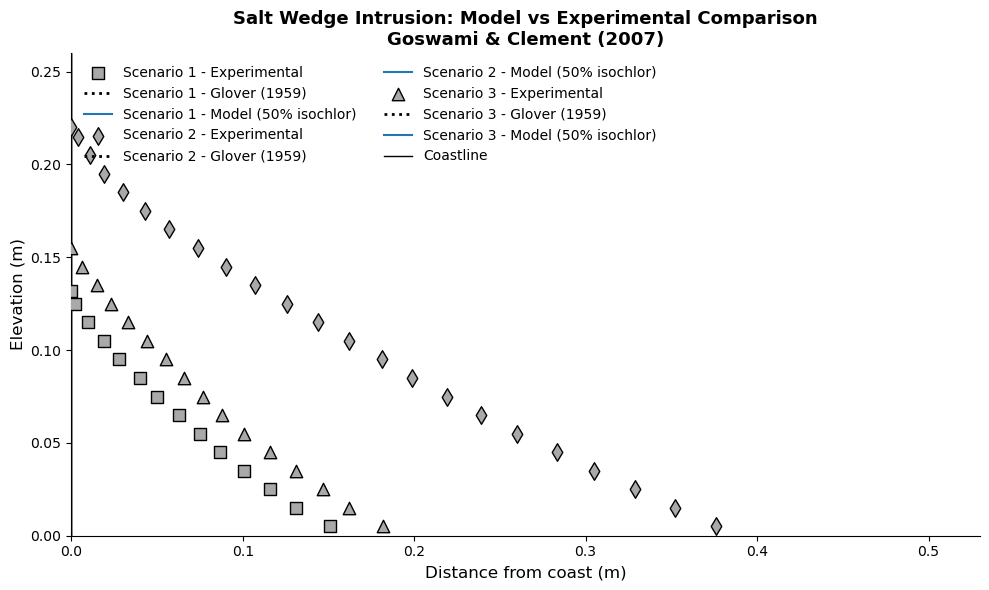

In [44]:
# Create figure with two subplots
markers = ['s', 'd', '^']  # Square, diamond, triangle
scenario_labels = ['Scenario 1', 'Scenario 2', 'Scenario 3']

fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(False)
ax.set_xlabel('Distance from coast (m)', fontsize=12)
ax.set_ylabel('Elevation (m)', fontsize=12)
ax.set_xlim(0.0, 0.53)
ax.set_ylim(0.0, 0.26)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

leg_data_all = []

for i in range(3):
    xc = f'x_ss{i + 1}'
    yc = f'y_ss{i + 1}'
    
    # Plot modeled mixing zone as shaded area (10% to 90% isochlor)
    leg_f = ax.fill_betweenx(ys[0], xs[i][0], xs[i][2], 
                              edgecolor='grey', facecolor='lightgrey', 
                              zorder=0, alpha=0.5)
    
    # Plot experimental data points
    leg_data = ax.scatter(df_exp[xc] / 100.0, df_exp[yc] / 100.0, 
                           marker=markers[i], facecolor='darkgray', 
                           edgecolor='black', s=80, 
                           label=f'{scenario_labels[i]} - Experimental', zorder=3)
    leg_data_all.append(leg_data)
    
    # Plot analytical solution (Glover 1959)
    leg_g, = ax.plot(xg, yg[i], ls=':', color='black', linewidth=2,
                     label=f'{scenario_labels[i]} - Glover (1959)', zorder=2)
    
    # Plot modeled 50% isochlor
    leg_m, = ax.plot(xs[i][1], ys[i], color='tab:blue', linewidth=1.5,
                     label=f'{scenario_labels[i]} - Model (50% isochlor)', zorder=2)

# Add coastline
ax.axvline(x=0, color='black', linewidth=1, linestyle='-', label='Coastline')

# Add legend
ax.legend(loc='upper left', frameon=False, fontsize=10, ncol=2)

# Add title
ax.set_title('Salt Wedge Intrusion: Model vs Experimental Comparison\nGoswami & Clement (2007)', 
             fontsize=13, fontweight='bold')

fig.tight_layout()

print("✓ Figure created")
plt.show()

## Step 8: Save Output Figures

In [ ]:
# Create output directory if it doesn't exist
output_dir = os.path.dirname(output_fig_pdf)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}")

# Save as PDF
fig.savefig(output_fig_pdf, dpi=300, bbox_inches='tight')
print(f"✓ Saved PDF figure: {output_fig_pdf}")

# Save as PNG
fig.savefig(output_fig_png, dpi=300, bbox_inches='tight')
print(f"✓ Saved PNG figure: {output_fig_png}")

✓ Saved PDF figure: benchmark_data/model_vs_experimental_salt_wedge.pdf
✓ Saved PNG figure: benchmark_data/model_vs_experimental_salt_wedge.png


## Summary: Analysis Complete

### Key Results:

**1. Fresh-Salt Water Mixing Zone Width**
- Calculated as distance between 10% and 90% isochlors
- Should be ~1 cm wide according to experiments

**2. Freshwater Flux Comparison**
- Compares model discharge to experimental measurements
- Shown in cm³/sec units

**3. Model-Data Misfit**
- Quantified using Mean Absolute Error (MAE) and RMSE
- Based on 50% isochlor position (0.5 salinity interface)

**4. Visualization**
- Model mixing zone shown as shaded gray region
- Experimental observations shown as colored data points
- Analytical solution (Glover 1959) shown as dashed line

### References:
- **Glover (1959)** - Analytical solution for coastal aquifer salt wedge
- **Goswami & Clement (2007)** - Experimental validation, WRR vol. 43

### Output Files:
- PDF: `benchmark_data/model_vs_experimental_salt_wedge.pdf`
- PNG: `benchmark_data/model_vs_experimental_salt_wedge.png`